# Homework08

Exercises to practice unsupervised learning with clustering

## Goals

- Get more practice with the ML flow: encode -> normalize -> train -> evaluate
- Understand the tradeoffs of modeling parameters
- Develop intuition for different clustering models and when to use them

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [3]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py

In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd

from os import listdir
from PIL import Image as PImage

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

from data_utils import balance_score, distance_score, silhouette_score, display_silhouette_plots
from data_utils import object_from_json_url

from image_utils import get_pixels, make_image

## Helmet Sizing

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/PSAM-5020-2026S-A/WK02) and then again in [Homework06](https://github.com/PSAM-5020-2026S-A/Homework06).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [5]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

Let's load it into a `DataFrame`, like last week.

In [6]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


### Unsupervised Learning

Let's pretend we are designing next-generation helmets with embedded over-the-ear headphones and we want to have a few options for sizes.

We could use clustering to see if there is a number of clusters that we can divide our population into, so each size covers a similar portion of the population.

We can follow similar steps to regression to create a clustering model that uses features about head and ear sizes:

1. Load dataset (done! 🎉)
2. Encode label features as numbers
3. Normalize the data
4. Separate the feature variables we want to consider (done below)
5. Pick a clustering algorithm
6. Determine number of clusters
7. Cluster data
8. Interpret results

For step $5$, it's fine to just pick an algorithm ahead of time to see what happens, but feel free to experiment and plot results for multiple clustering methods.

In [7]:
## Encode non-numerical features

ansur_df = pd.json_normalize(ansur_data)

ansur_df = pd.json_normalize(ansur_data)                 
ansur_df["gender"] = ansur_df["gender"].map({"M": 1, "F": 0}) 

ansur_df.head()

## Normalize the data

scaler = StandardScaler()
ansur_scaler = StandardScaler().set_output(transform="pandas")  
ansur_scaled_df = ansur_scaler.fit_transform(ansur_df)


In [8]:
## Separate the features we want to consider
ansur_features = ansur_scaled_df[["head.height", "head.circumference", "ear.length", "ear.breadth", "ear.protrusion"]]

balance score: 0.9802678571428571
silhouette score: 0.18734734772048675
distance score: 1.6499580391152986


/tmp/ipykernel_11652/2076452695.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ansur_features["kmeans_cluster"] = clustering_labels


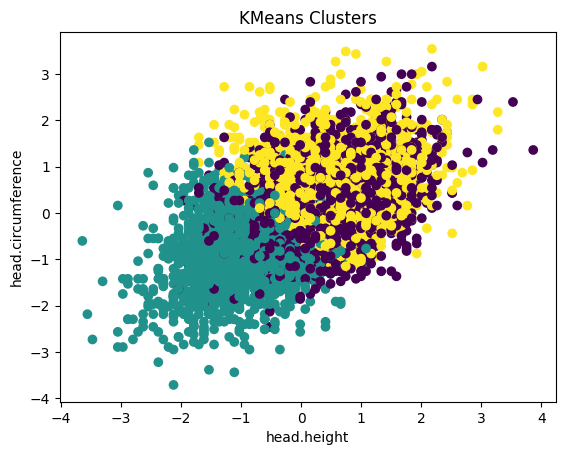

In [9]:
## Create Clustering model

clustering = KMeans(n_clusters=3, random_state=0)

## Run the model(s) on the data

clustering_labels = clustering.fit_predict(ansur_features)

## Check errors

print("balance score:", balance_score(clustering_labels))
print("silhouette score:", silhouette_score(ansur_features, clustering_labels))
print("distance score:", distance_score(ansur_features, clustering_labels))

## Plot clusters as function of 2 or 3 variables

ansur_features["kmeans_cluster"] = clustering_labels

plt.scatter(
    ansur_features["head.height"],
    ansur_features["head.circumference"],
    c=ansur_features["kmeans_cluster"]
)
plt.xlabel("head.height")
plt.ylabel("head.circumference")
plt.title("KMeans Clusters")
plt.show()

### Interpretation

<span style="color:hotpink;">
Which clustering algorithm did you choose?<br>
Did you try a different one?<br>
Do the clusters make sense ? Do they look balanced ?
</span>

<span style="color:hotpink;">

I did the kmeans clustering algorithm, the clusters look balanced concurrent to a high balance score. 
</span>

## Figure out how many cluster

Experiment with the number of clusters to see if the initial choice makes sense.

The [WK08](https://github.com/PSAM-5020-2026S-A/WK08) notebook had a for loop that can be used to plot errors versus number of clusters.

balance score: 0.9802678571428571
silhouette score: 0.28806537135664895
distance score: 1.6499580391152986


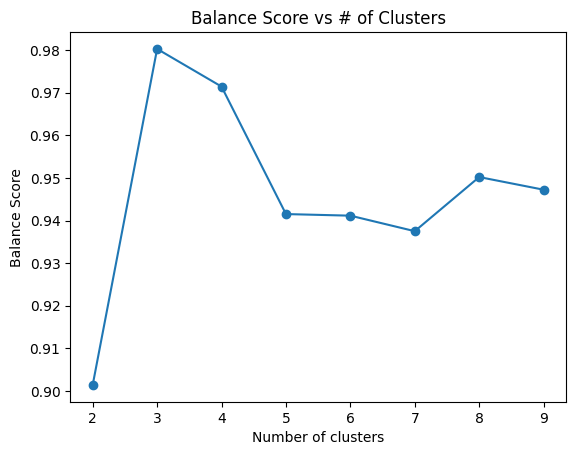

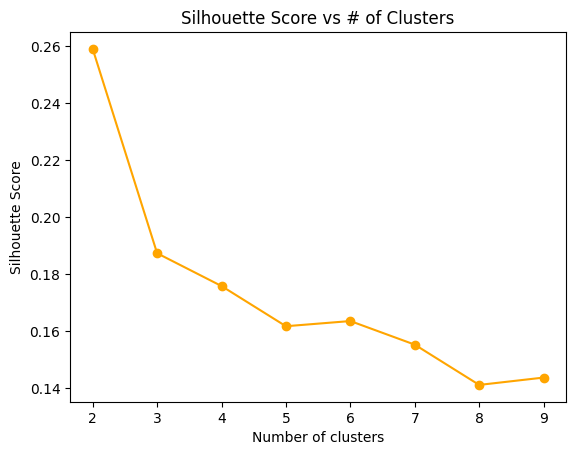

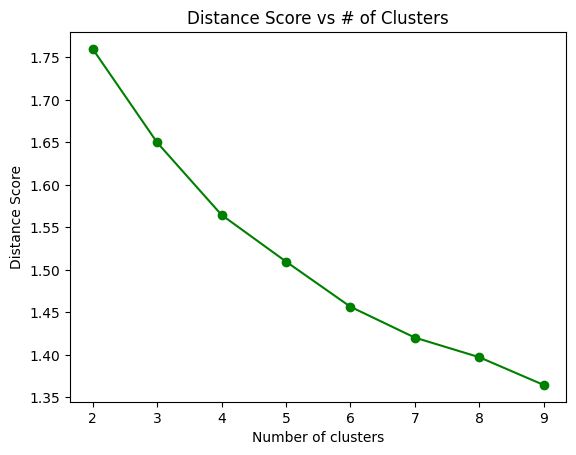

In [10]:
## Plot errors and pick how many cluster

cluster_range = range(2, 10)  

balance_scores = []
silhouette_scores = []
distance_scores = []

features_only = ansur_features.drop(columns="kmeans_cluster", errors='ignore')

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(features_only)
    
    balance_scores.append(balance_score(labels))
    silhouette_scores.append(silhouette_score(features_only, labels))
    distance_scores.append(distance_score(features_only, labels))

print("balance score:", balance_score(clustering_labels))
print("silhouette score:", silhouette_score(ansur_features, clustering_labels))
print("distance score:", distance_score(ansur_features, clustering_labels))

plt.plot(cluster_range, balance_scores, marker='o')
plt.title("Balance Score vs # of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Balance Score")
plt.show()

plt.plot(cluster_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs # of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

plt.plot(cluster_range, distance_scores, marker='o', color='green')
plt.title("Distance Score vs # of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Distance Score")
plt.show()


### Interpretation

<span style="color:hotpink;">
Based on the graphs of errors versus number of clusters, does it look like we should change the initial number of clusters ?<br>
How many clusters should we use ? Why ?
</span>

<span style="color:hotpink;">
The distance score is a little confusing to me, but I think should go with 4 because the silhouette is fairly high and the balance also maintains? I am not sure about this answer. 
</span>

### Revise Number of Clusters.

Re-run with the new number of clusters and plot the data in $2D$ or $3D$.

This can be the same graph as above.

/tmp/ipykernel_11652/1025907059.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ansur_features["kmeans_cluster"] = clustering_labels


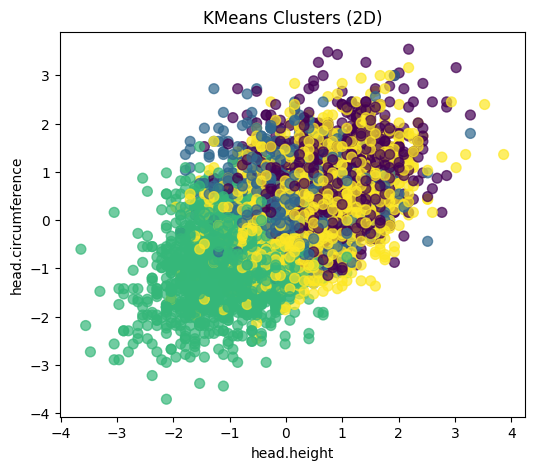

balance score: 0.7804761904761905
silhouette score: 0.2640118899215204
distance score: 1.5624024401632455


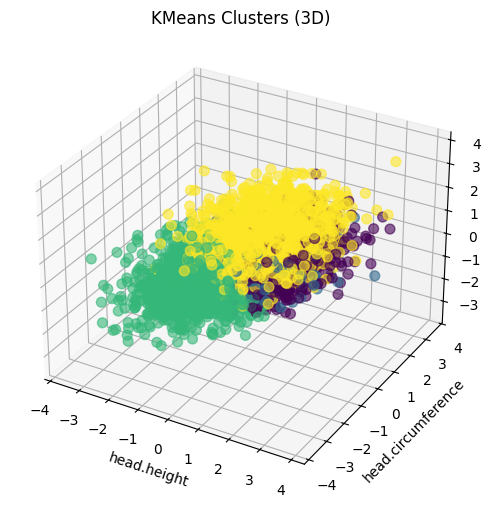

In [11]:
## Re-run clustering with final number of clusters

## Create Clustering model

clustering = KMeans(n_clusters=4, random_state=0)

## Run the model(s) on the data

clustering_labels = clustering.fit_predict(ansur_features)

ansur_features["kmeans_cluster"] = clustering_labels

plt.figure(figsize=(6,5))
plt.scatter(
    ansur_features["head.height"],
    ansur_features["head.circumference"],
    c=ansur_features["kmeans_cluster"],
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.xlabel("head.height")
plt.ylabel("head.circumference")
plt.title("KMeans Clusters (2D)")
plt.show()

## Run the model on the training data

## Check errors

print("balance score:", balance_score(clustering_labels))
print("silhouette score:", silhouette_score(ansur_features, clustering_labels))
print("distance score:", distance_score(ansur_features, clustering_labels))

## Plot in 3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x_feature = "head.height"
y_feature = "head.circumference"
z_feature = "ear.length"

ax.scatter(
    ansur_features[x_feature],
    ansur_features[y_feature],
    ansur_features[z_feature],
    c=ansur_features["kmeans_cluster"],
    cmap='viridis',
    s=50,
    alpha=0.6
)

ax.set_xlabel(x_feature)
ax.set_ylabel(y_feature)
ax.set_zlabel(z_feature)
ax.set_title("KMeans Clusters (3D)")
plt.show()

### Interpretation

<span style="color:hotpink;">
Do these look better than the original number of clusters?
</span>

<span style="color:hotpink;">
I think yes, the balance is still very high, the silhouette is fairly middle and the distance is still alright. I am looking at this based on the numbers and comparing them!
</span>

## Image Organization

We have a dataset of about $600$ flower images that we might want to classify by species... eventually.

What we want to do first is take a look at all of the images and see what kind of images we have, what kind of colors our flowers have and see if there's any other visual information that could help us classify these images later.

We'll see how to use clustering and distances to organize our images by color to create a visualization that we cna use to get to know our dataset.

### Load Dataset

The following cell downloads the dataset:

In [12]:
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/flowers.tar.gz | tar xz

Then, we can take a look at a few of the images:

In [13]:
IMG_DIR = "./data/image/flowers"

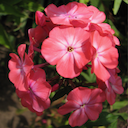

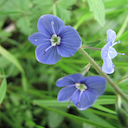

In [14]:
display(PImage.open(f"{IMG_DIR}/00_001.png"))
display(PImage.open(f"{IMG_DIR}/15_001.png"))

### Find Representative Colors

The overall process for organizing our images by color will be something like this:

1. Iterate over all files in the `data/image/flowers` directory, open each image file and treat it as a dataset
   1. Load image into a `DataFrame` where each pixel is a row and R,G,B values are columns/features
   2. Cluster into $2$ - $16$ colors
   3. Pick $3$ or $4$ representative colors
   4. Store image filenames and their representative colors in a Python object
2. Once all images have been processed we can order our dataset by different color characteristics: white to black, red to blue, hue value, brightness

### One Image

Let's step through the process of getting representative colors for one image, and then we can repeat this in a loop to process all of the flower images.

#### Open Image

The `PIL` library does all the work here:

In [15]:
# Open image
fname = "00_001.png"
pimg = PImage.open(f"{IMG_DIR}/{fname}").convert("RGB")

#### Put into `DataFrame`

We get the pixels and make a dataset/`DataFrame` out of them:

In [16]:
# Load into DataFrame
pxs = get_pixels(pimg)
pxs_df = pd.DataFrame(pxs, columns=["R", "G", "B"])

#### Cluster colors

Create a clustering object, cluster colors into $8$ clusters with `fit_predict()` and take a look at our color palette (`cluster_centers_`):

In [17]:
# TODO: Create Clustering object

kmeans = KMeans(n_clusters=8, random_state=0)

# TODO: Cluster by color

labels = kmeans.fit_predict(pxs)

# TODO: Take a look at the color palette (cluster_centers_)

color_palette = kmeans.cluster_centers_
print(color_palette)

[[130.9910778   35.06995004  48.38365453]
 [246.32361242 163.8494826  191.13546566]
 [ 36.18280825  35.61376896  20.3041618 ]
 [240.43069695 111.40837901 133.29561472]
 [100.41245136 100.29280156  51.78307393]
 [195.2058296   62.2793722   82.067713  ]
 [ 14.14159664  15.82689076  11.21344538]
 [ 70.19931663  59.85193622  33.60820046]]


#### Checkpoint

<span style="color:hotpink;">
Does anything stand out about the colors?
</span>

<span style="color:hotpink;">I think 1, 2, 4, 5 have a lot of R, 3 and 7 are really dark and have low numbers</span>

#### Reconstruct Image

Since we're only doing one image for now, let's take a look at the clustering result.

This is like in the lecture notebook. We'll start with an empty pixel array and as we iterate through the `DataFrame` of cluster ids we append the corresponding colors to it.

In [18]:
#kmeans = KMeans(n_clusters=2, random_state=0)
#labels = kmeans.fit_predict(pxs)
#color_palette = kmeans.cluster_centers_

#pxs_post = []
#for label in labels:
#   pxs_post.append(tuple(color_palette[label].astype(int)))

#display(make_image(pxs_post, width=pimg.size[0]))

In [19]:
#kmeans = KMeans(n_clusters=16, random_state=0)
#labels = kmeans.fit_predict(pxs)
#color_palette = kmeans.cluster_centers_

#pxs_post = []
#for label in labels:
#    pxs_post.append(tuple(color_palette[label].astype(int)))

#display(make_image(pxs_post, width=pimg.size[0]))

In [20]:
# TODO: create empty pixel array
pxs_post = []
#print(pxs_post[:3])

# TODO: iterate through resulting list of cluster ids
for label in labels:
    pxs_post.append(tuple(color_palette[label].astype(int)))
    
# TODO: append corresponding color value to pixel array

print(pxs_post[:3])

[(np.int64(14), np.int64(15), np.int64(11)), (np.int64(14), np.int64(15), np.int64(11)), (np.int64(14), np.int64(15), np.int64(11))]


Now we can look at the image. If this next cell gives errors about using `float` values in images, just make sure the pixel values that are being appended above are all whole number `int` values.

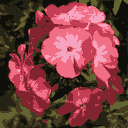

In [21]:
display(make_image(pxs_post, width=pimg.size[0]))

#### Checkpoint

<span style="color:hotpink;">
How does changing the number of clusters affect the resulting image?<br>Try some lower values like <code>2</code> and <code>4</code>, and also some higher ones like <code>12</code> and <code>16</code>. Take a look at a different image.
</span>

<span style="color:hotpink;">
I think changing the clusters give more categories for colors to be sorted. 
When there's 16, there's way more colors in the color palette so more information for your eye to be tricked into it having more details. It literally has more colors. 
</span>

#### Pick Colors

Ok, we have some representative colors for our images. We should keep more than one color, but maybe we don't have to keep $12$.

If we put our predictions in a `DataFrame` we can use the `value_counts()` function of our `DataFrame` to see how many pixels are represented by each of our cluster colors, and get the result ordered by most frequent to less frequent cluster id:

In [22]:
# cluster ids and pixel counts, ordered by descending counts
px_clusters_df = pd.DataFrame(labels, columns=["clusters"])
ccounts = px_clusters_df["clusters"].value_counts()
display(ccounts)

clusters
0    2804
2    2574
3    2553
6    2387
5    2230
7    1756
1    1064
4    1016
Name: count, dtype: int64

Since what we are really trying to do here is get some information about the colors of the flowers present in our images, and given the type of images we have, we can start by assuming that the flower colors will be in the top-$4$ clusters returned by `value_counts()`.

We can revisit this assumption later. We might also want to add some filters here to ignore sky and vegetation colors (blues and greens) and only keep flower colors.

For now, let's just grab the top $4$ colors from `value_counts()`, remembering we want to keep their rounded `int` values and not the default `float` values in `cluster_centers_`.

In [23]:
# Object to keep colors for each file
file_info = {
  "filename": fname,
  "colors": []
}

# TODO: go through ccounts.index and get corresponding colors for each clusters

for cluster_id in ccounts.index[:4]:
    #color = tuple(color_palette[cluster_id].astype(int))
    color = [int(v) for v in color_palette[cluster_id]]
    file_info["colors"].append(color)

# TODO: add top-4 colors to the "colors" key of the file_color_info object

print(file_info)

{'filename': '00_001.png', 'colors': [[130, 35, 48], [36, 35, 20], [240, 111, 133], [14, 15, 11]]}


In [24]:
display(file_info)

{'filename': '00_001.png',
 'colors': [[130, 35, 48], [36, 35, 20], [240, 111, 133], [14, 15, 11]]}

#### Checkpoint

<span style="color:hotpink;">
Why might we want to cluster into <code>8</code> or even <code>12</code> colors when in the end we're only keeping <code>4</code>?
</span>

<span style="color:hotpink;">I think it gives you more colors to eventually throw away, assuming the top 4 are gonna be the ones we are most interested in, it'll just throw away the bottom 4 of uninformitive or unhelpful numbers. </span>

### Iterate and Cluster

We've processed one image, now let's process $600$... for-loops FTW!

We'll need to loop through all of the images in our directory and repeat the process above for each one of them.

We can create a function that takes a filename as input and returns the top-$4$ colors for that image, or... we can just put all of the clustering logic in the body of a for loop. Whichever is easiest.

Let's get started.

In [25]:
# list of all files in the flowers directory
flower_files = sorted([f for f in listdir(IMG_DIR) if f.endswith(".png")])

Here's the loop. In the end we want our `file_colors` list to have objects that have a filename and $4$ colors associated with each filename. Something like:

```py
[
  {
    "filename": "00_001.png",
    "colors": [[12,44,12], [112,144,62],  [12,84,112], [212,144,102]]
  },
  {
    "filename": "00_002.png",
    "colors": [[22,24,28], [112,114,122], [128,200,2], [250,240,230]]
  },
  ...
]
```

This can take a while to run (up to a minute for $600$ images). We can use slicing to test our logic on a subset of `flower_files` before processing all $600$ images.

In [26]:
# List to keep colors for each file
file_colors = []

# TODO: get colors for each image
for fname in flower_files:
    pimg = PImage.open(f"{IMG_DIR}/{fname}").convert("RGB")
    pxs = get_pixels(pimg)

    kmeans = KMeans(n_clusters=8, random_state=0)
    labels = kmeans.fit_predict(pxs)
    color_palette = kmeans.cluster_centers_

    px_clusters = labels
    px_cluster_df = pd.DataFrame(px_clusters, columns=["clusters"])
    ccounts = px_clusters_df["clusters"].value_counts()

    colors = []
    for cluster_id in ccounts.index[:4]:
        color = [int(v) for v in color_palette[cluster_id]]
        colors.append(color)

    file_colors.append({
        "filename": fname,
        "colors": colors })
    
  # TODO: add logic here

  # TODO: add filename+colors object to list of objects # Change this

#### Order Images (almost)

We have a list with objects that keep track of filenames and representative colors. We could create a `DataFrame` or csv dataset with these, but let's go ahead and just use this directly in this format.

What we want to do is re-order our list of objects, but using a `key` function that takes each object's colors into consideration.

We'll look into how to do this dynamically later, but for now let's order our images by something like _brightness_. It's _like_ brightness because what we'll do is measure how close each image is to the white color `(255,255,255)`.

We'll need some helper functions first:

- `color_distance()`: takes $2$ colors and returns the distance between them
- `min_color_distance()`: given a reference color and a list of colors, returns the distance between the reference color and the closest color in the list

In [27]:
# TODO: implement function that returns distance between two colors
def color_distance(c0, c1):
    distance = sum((v1 - v0) ** 2 for v0, v1 in zip(c0, c1)) ** 0.5
    return distance

Some tests for the `color_distance()` function:

In [28]:
# Some tests for the color_distance() function
print(color_distance([0,0,0], [255,255,255]), "should be", 255*3**.5)
print(color_distance([0,100,0], [100,100,0]), "should be", 100)
print(color_distance([55,222,120], [91,51,192]), "should be", 189)
print(color_distance([147,207,246], [87,57,50]), "should be", 254)
print(color_distance([12,250,126], [112,10,195]), "should be", 269)
print(color_distance([106,71,61], [105,136,100]), "should be", 75.81)

441.6729559300637 should be 441.67295593006367
100.0 should be 100
189.0 should be 189
254.0 should be 254
269.0 should be 269
75.80897044545586 should be 75.81


In [29]:
# TODO: implement function that returns minimum distance between a reference color and colors from a list
def min_color_distance(ref_color, color_list):
    distance = [color_distance(ref_color, color) for color in color_list]
    return min(distance)

Three tests for the `min_color_distance()` function:

In [30]:
# Some tests for the color_distance() function
print(min_color_distance([0,0,0], [[255,255,255],[0,100,0],[100,100,0],[58,58,58]]), "should be", 100)
print(min_color_distance([0,0,0], [[255,255,255],[0,100,0],[100,100,0],[58,57,58]]), "should be", 99.88)
print(min_color_distance([91,51,192], [[147,207,246],[87,57,50],[12,250,126],[112,10,195]]), "should be", 46.16)

100.0 should be 100
99.88493379884676 should be 99.88
46.16275555033516 should be 46.16


#### Order Images (for real now)

Alright. We have a function that can be used to order our images by their distance to a given color.

Let's order our images by how close they are to the brightest color `(255,255,255)`. We'll define a `key` function that, given an object from our `file_colors` list, returns how close that image is to the color `(255,255,255)`.

In [31]:
# TODO: implement function that returns how close our image is to the color white
def by_bright_dist(A):
    return min_color_distance([255, 255, 255], A["colors"])

Order the list and write out a `JSON` file with the image order.

In [32]:
file_colors_sorted = sorted(file_colors, key=by_bright_dist)

In [91]:
files_sorted = [A["filename"] for A in file_colors_sorted]

with open("./data/flower_order.json", "w") as ofp:
  json.dump(files_sorted, ofp)

### Viewing Results

We can check the results by running a webserver and looking at a simple web page that orders the images according to the resulting `JSON` file from above.

We'll make use of the [`Live Server`](https://marketplace.visualstudio.com/items?itemName=ritwickdey.LiveServer) VSCode extension.

We can start the server by clicking on the "_Go Live_" button towards the right hand side of the bar at the very bottom of our text editor:

<img src="./imgs/go_live.jpg" width="600px">

Clicking the "_Go Live_" button in Codespace should open up a new tab with a plain html navigation view of our repository. Clicking on the `html/` directory should open up a web page with all of the flower images. If not, you can use your Codespace url to try to find the web server address.

If your Codespace url is something like:<br>`https://mango-special-giggle-v6v7asd322f7p6.github.dev/`

Then, the webserver should be running at:<br>`https://mango-special-giggle-v6v7asd322f7p6-5500.app.github.dev/`

### Review, Contemplate, Experiment

Yes, images with white parts are towards the beginning, but the images towards the end aren't necessarily the ones with dark flowers, but are the ones that have all of their representative colors farthest away from white `(255,255,255)`, which includes very saturated colors/images.

A couple of interesting experiments here could be:
- Decrease the number of clusters or the number of colors kept after clustering.
- Use different colors as the reference for the distance functions. For example, create `by_gold_dist()` or `by_purple_dist()` functions to use as the `key` for sorting.
- Order the list of cluster colors by [hue](https://stackoverflow.com/questions/23090019/fastest-formula-to-get-hue-from-rgb). This can be a bit tricky to get right because some colors, like white, black and gray, don't have a unique value for hue, but depend on other aspects of the color, like saturation and lightness, to be well-defined.

In [ ]:
def rgb_hue(rgb):
    r,g,b = [x / 255 for x in rgb]
    colormax = max(r,g,b)
    colormin = min(r,g,b)
    difference = colormax - colormin

    if difference == 0:
        return -1
    
    if colormax == r:
        return (60 * ((g - b) / difference) % 6)
    elif colormax == g:
        return (60 * ((b - r) / difference) + 2)
    else:  # colormax == b
        return (60 * ((r - g) / difference) + 4)

    return hue


def min_hue_of_file(file_info):
    hues = [rgb_hue(color) for color in file_info["colors"]]
    return min(hues)

In [ ]:
# TODO: experiment with number of clusters, number of colors, reference colors or hue distances

file_colors_sorted = sorted(file_colors, key=min_hue_of_file)  

files_sorted = [A["filename"] for A in file_colors_sorted]

with open("./data/flower_order.json", "w") as ofp:
  json.dump(files_sorted, ofp)

### Interpretation

<span style="color:hotpink;">
What did you try ? What happened ?
</span>

<span style="color:hotpink;">
I tried to do the hue sorting! It definitely changed to order but not sure it was that effective in the long run. It has moments where it works like all of the yellows are more generally at the top and reds and pinks are generally at the bottom. and if you scroll down and up the page super fast to blur everything for your eye you vaguely see a kind of yellow to blueish to reddish shift. pretty cool... though if you're looking one by one some of the parts in the middle get a little confusing.


### Conclusion

It's challenging to define a set of functions that will perfectly order our flowers by color without first having to define very specific color values for filtering and corner-cases. At a high-level, we can imagine that this is because color is a $3$-dimensional value, and we're using it to organize our images into a single-dimensional order.

The beginning of our ordering is usually pretty good, since there's only one way for a color to be _close_ to our reference color, but the ordering gets less consistent towards the end because there are many different ways for a color to be _far_ from the reference color.

Next week we'll see a very powerful technique that, amongst other things, will help us get around this kind of "_dimensionality mismatch_".